# Análise de Resultados - GTE Med

Este notebook apresenta a análise exploratória dos resultados gerados pelo sistema **VeriFact**, que utiliza a abordagem *LLM-as-a-Judge* para verificar proposições clínicas extraídas de resumos de internação (Brief Hospital Course) contra o prontuário eletrônico do paciente (EHR).

Cada proposição recebe um dos três veredictos possíveis:
- 🟢 **Supported** — a proposição é sustentada pelo EHR
- 🔴 **Not Supported** — a proposição contradiz ou não é confirmada pelo EHR
- ⚫ **Not Addressed** — o EHR não contém informação suficiente para avaliar a proposição

O experimento avalia duas condições de recuperação de contexto:
- **EHR Completo** (`reference_only_admission=False`): recupera trechos de todo o histórico do paciente
- **Só Admissão** (`reference_only_admission=True`): recupera apenas notas da internação atual

## 1. Configuração do Ambiente
Importação das bibliotecas necessárias para análise de dados, visualização e métricas de concordância entre avaliadores.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef, ConfusionMatrixDisplay
from irrCAC.raw import CAC

## 2. Carregamento dos Dados
Carrega os arquivos consolidados do experimento selecionado. O diretório `RESULTS_DIR` aponta para a configuração de embedding/LLM desejada.

- `verdicts.feather` — tabela com uma linha por proposição, contendo o veredicto, o texto da proposição, a razão do juiz e o contexto EHR recuperado
- `score_reports.feather` — tabela com métricas agregadas por paciente

In [32]:
RESULTS_DIR = Path('../data/experimento/Gte_Med_DeepSeek/score_reports')
VERDICT_COLORS = {'Supported': '#2ecc71', 'Not Supported': '#e74c3c', 'Not Addressed': '#95a5a6'}

verdicts = pd.read_feather(RESULTS_DIR / 'verdicts.feather')
score_reports = pd.read_feather(RESULTS_DIR / 'score_reports.feather')

print(f'Total de veredictos: {len(verdicts)}')
print(f'Total de score reports: {len(score_reports)}')

Total de veredictos: 1996
Total de score reports: 200


## 3. Comparação com Ground Truth Humano

Compara os veredictos do VeriFact com o *ground truth* anotado por clínicos humanos, disponível no dataset **VeriFact-BHC**.

São calculadas duas métricas:
- **Matriz de Confusão** — visualiza os acertos e erros por classe de veredicto
- **Gwet's AC1** — métrica de concordância entre avaliadores robusta ao desequilíbrio de classes (preferível ao Kappa de Cohen neste contexto), com intervalo de confiança de 95%

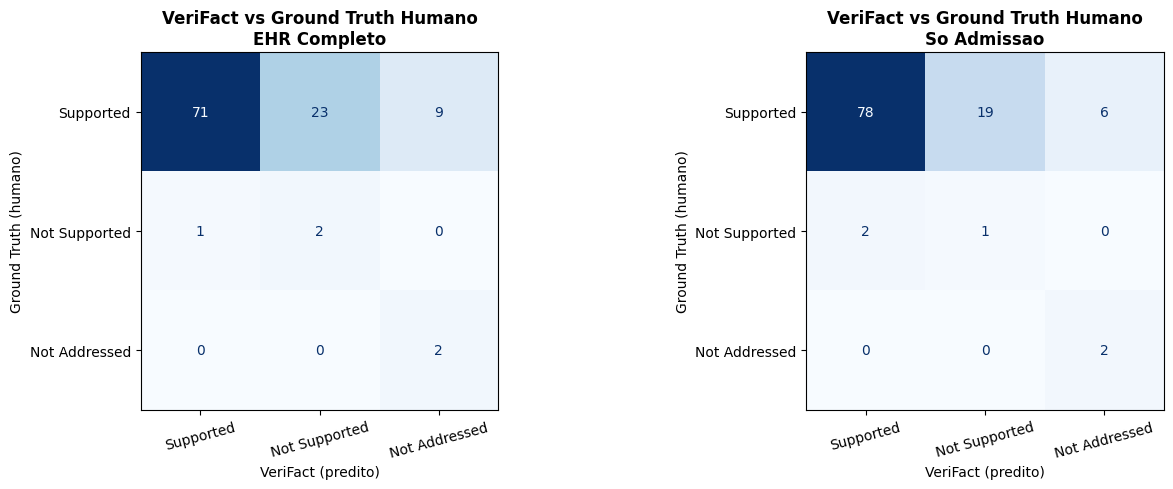


=== EHR Completo (n=108) ===
               precision    recall  f1-score   support

    Supported       0.99      0.69      0.81       103
Not Supported       0.08      0.67      0.14         3
Not Addressed       0.18      1.00      0.31         2

     accuracy                           0.69       108
    macro avg       0.42      0.79      0.42       108
 weighted avg       0.95      0.69      0.78       108

Gwet's AC1 = 0.6355  (IC95% 0.5178 - 0.7533)   p = 0.0e+00

=== So Admissao (n=108) ===
               precision    recall  f1-score   support

    Supported       0.97      0.76      0.85       103
Not Supported       0.05      0.33      0.09         3
Not Addressed       0.25      1.00      0.40         2

     accuracy                           0.75       108
    macro avg       0.42      0.70      0.45       108
 weighted avg       0.94      0.75      0.82       108

Gwet's AC1 = 0.7112  (IC95% 0.6054 - 0.8170)   p = 0.0e+00


In [33]:
# Carregar ground truth
props = pd.read_csv('../data/propositions.csv.gz')
human_verdicts = pd.read_csv('../data/human_verdicts.csv.gz')

# Juntar subject_id ao ground truth e filtrar paciente
top10_subjects = props['subject_id'].unique()[:10]

gt = human_verdicts.merge(props[['proposition_id', 'subject_id']], on='proposition_id')
gt = gt[gt.subject_id.isin(top10_subjects)][['proposition_id', 'human_gt']].set_index('proposition_id')

label_order = ['Supported', 'Not Supported', 'Not Addressed']

# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (ref_only, label) in zip(axes, [(False, 'EHR Completo'), (True, 'So Admissao')]):
    subset = verdicts[verdicts.reference_only_admission == ref_only][['verdict']].copy()
    merged = subset.join(gt.rename(columns={'human_gt': 'ground_truth'}), how='inner')

    cm = confusion_matrix(merged['ground_truth'], merged['verdict'], labels=label_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'VeriFact vs Ground Truth Humano\n{label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('VeriFact (predito)')
    ax.set_ylabel('Ground Truth (humano)')
    for tick in ax.get_xticklabels():
        tick.set_rotation(15)

plt.tight_layout()
plt.show()

# --- Classification Report + Gwet's AC1 ---
for ref_only, label in [(False, 'EHR Completo'), (True, 'So Admissao')]:
    subset = verdicts[verdicts.reference_only_admission == ref_only][['verdict']].copy()
    merged = subset.join(gt.rename(columns={'human_gt': 'ground_truth'}), how='inner')
    print(f'\n=== {label} (n={len(merged)}) ===')
    print(classification_report(merged['ground_truth'], merged['verdict'], labels=label_order, zero_division=0))

    # Gwet's AC1 — DataFrame com 1 coluna por rater
    ratings = pd.DataFrame({'Human': merged['ground_truth'].values, 'VeriFact': merged['verdict'].values})
    ac1 = CAC(ratings, categories=label_order).gwet()
    coef = ac1['est']['coefficient_value']
    lo, hi = ac1['est']['confidence_interval']
    p = ac1['est']['p_value']
    print(f"Gwet's AC1 = {coef:.4f}  (IC95% {lo:.4f} - {hi:.4f})   p = {p:.1e}")

## 4. Coeficiente de Correlação de Matthews (MCC)

O **MCC** (Matthews Correlation Coefficient) é uma métrica de classificação multiclasse que considera todos os elementos da matriz de confusão. Varia de -1 (predição inversa perfeita) a +1 (predição perfeita), com 0 indicando desempenho aleatório.

É especialmente útil quando as classes são desbalanceadas, como neste dataset onde *Supported* é majoritária.

In [34]:

label_order = ['Supported', 'Not Supported', 'Not Addressed']

for ref_only, label in [(False, 'EHR Completo'), (True, 'So Admissao')]:
    subset = verdicts[verdicts.reference_only_admission == ref_only][['verdict']].copy()
    merged = subset.join(gt.rename(columns={'human_gt': 'ground_truth'}), how='inner')
    mcc = matthews_corrcoef(merged['ground_truth'], merged['verdict'])
    print(f'{label}: MCC = {mcc:.4f}')

EHR Completo: MCC = 0.2401
So Admissao: MCC = 0.1932


## 5. Exemplos Qualitativos por Veredicto

Exibe um exemplo de cada classe de veredicto (*Supported*, *Not Addressed*, *Not Supported*) para as duas condições de recuperação de contexto.

Para cada exemplo são mostrados:
- O texto da proposição avaliada
- O veredicto atribuído pelo LLM-as-a-Judge
- A razão textual fornecida pelo juiz
- Os trechos do EHR recuperados como contexto de referência

In [35]:
icons = {'Supported': 'SUPPORTED', 'Not Supported': 'NOT SUPPORTED', 'Not Addressed': 'NOT ADDRESSED'}
sample = verdicts[verdicts.reference_only_admission == True].head(3)

for _, row in sample.iterrows():
    print(f'[{icons.get(row.verdict, row.verdict)}] {row.text}')
    print(f'  Razao: {row.reason}')
    print(f'  Contexto EHR (primeiras 5 entradas):')
    for line in row.reference.strip().split('\n')[:200]:
        if line.strip():
            print(f'    {line}')
    print()

[SUPPORTED] The patient developed right lower quadrant abdominal pain, which resolved, and experienced delirium, for which she was treated with haldol. 
  Razao: The reference notes that the patient had abdominal pain and received haldol for agitation/delirium, which matches the text's description of right lower quadrant abdominal pain that resolved and delirium treated with haldol.
  Contexto EHR (primeiras 5 entradas):
    Hospital Admission Start: 2194-01-23 01:25:00
    Hospital Admission End: 2194-01-30 11:30:00
    Electronic Health Record Context
    Ordered by Time (Earliest to Latest):
    1. Date: 2194-01-25, Time: 12:14:00, Note Category: Physician, Note Description: Physician Attending Progress Note | Text: Now with agitation and abd pain.
    2. Date: 2194-01-25, Time: 13:03:00, Note Category: Respiratory, Note Description: Respiratory Care Shift Note | Text: Also
       c/o abdominal discomfort w/ some relief w/ IV MSO4 given by RN. 
    3. Date: 2194-01-26, Time: 08:00:0

In [36]:
pd.set_option('display.max_colwidth', 120)
for ref_only, label in [(False, 'EHR Completo'), (True, 'So Admissao')]:
    print(f'\n{"="*80}')
    print(f'  {label}')
    print(f'{"="*80}')
    subset = verdicts[verdicts.reference_only_admission == ref_only][['text', 'verdict', 'reason', 'reference']].copy()
    subset.index = range(1, len(subset) + 1)
    
    sample = pd.concat([
        subset[subset.verdict == v].iloc[:1]
        for v in ['Supported', 'Not Addressed', 'Not Supported']
        if not subset[subset.verdict == v].empty
    ])
    
    display(sample.style.apply(
        lambda row: ['', f'background-color: {VERDICT_COLORS.get(row.verdict, "white")}33; font-weight: bold', '', ''],
        axis=1
    ))



  EHR Completo


,text,verdict,reason,reference
1,"The patient developed right lower quadrant abdominal pain, which resolved, and experienced delirium, for which she was treated with haldol.",Supported,"The reference context confirms that the patient experienced abdominal pain and delirium, and was treated with haldol for agitation, which matches the text.","Hospital Admission Start: 2194-01-23 01:25:00 Hospital Admission End: 2194-01-30 11:30:00 Electronic Health Record Context Ordered by Time (Earliest to Latest): 1. Date: 2194-01-09, Time: 08:11:00, Note Category: Nursing, Note Description: Nursing Progress Note | Text: haldol. 2. Date: 2194-01-25, Time: 12:14:00, Note Category: Physician, Note Description: Physician Attending Progress Note | Text: Now with agitation and abd pain. 3. Date: 2194-01-26, Time: 08:00:00, Note Category: Physician, Note Description: Physician Resident Progress Note | Text: Chief Complaint: 24 Hour Events: - Patient received low dose 0.25 to 0.5 ativan yesterday for agitation - She received morphine IV 1 mg x 2 for abdominal pain - She received 0.25 mg IV haldol this morning - LFTs/amylase/lipase were normal - C diff was ordered, however, no stools yet - CXR no acute process, moderate to large right pleural effusion - KUB without obstruction, 4. Date: 2194-01-26, Time: 11:56:00, Note Category: Physician, Note Description: Physician Attending Progress Note | Text: Now appears delirious, trying to avoid benzos, just using haldol. 5. Date: 2194-01-26, Time: 11:56:00, Note Category: Physician, Note Description: Physician Attending Progress Note | Text: 24 Hour Events: Recieved haldol for agitation."
33,"Later in his hospital course, the patient's condition stabilized, and he was able to be taken off CRRT.",Not Addressed,"The reference context does not mention the patient being taken off CRRT or his condition stabilizing later in the hospital course. It only describes ongoing CRRT use and a stable condition at various points, but no discontinuation of CRRT.","Hospital Admission Start: 2110-06-04 18:56:00 Hospital Admission End: 2110-06-28 14:29:00 Electronic Health Record Context Ordered by Time (Earliest to Latest): 1. Date: 2109-07-13, Time: 09:50:00, Note Category: Physician, Note Description: Physician Attending Progress Note | Text: For now, the patient is stable without any more episodes. 2. Date: 2109-07-13, Time: 09:50:00, Note Category: Physician, Note Description: Physician Attending Progress Note | Text: For now, the patient is stable without any more episodes. 3. Date: 2110-05-05, Time: 03:25:00, Note Category: Physician, Note Description: Physician Resident Admission Note | Text: He was discharged to rehab with furosemide 120 mg [**Hospital1 **]. 4. Date: 2110-05-23, Time: Unknown, Note Category: Discharge summary, Note Description: Report | Text: His HCT stabilized on [**5-6**] and remained stable for the remainder of his hospitalization. 5. Date: 2110-05-23, Time: Unknown, Note Category: Discharge summary, Note Description: Report | Text: He was discharged to rehab with furosemide 120 mg [**Hospital1 **]. 6. Date: 2110-06-14, Time: 06:18:00, Note Category: Nursing, Note Description: Nursing Progress Note | Text: Acidosis resolved with CRRT. 7. Date: 2110-06-14, Time: 06:18:00, Note Category: Nursing, Note Description: Nursing Progress Note | Text: Events Overnight: The pt had an uneventful night, tolerating aggressive fluid removal via CRRT. 8. Date: 2110-06-19, Time: 03:31:00, Note Category: Nursing, Note Description: Nursing Progress Note | Text: Plan: Continue CRRT with aggressive fluid removal pending repeat discussion w/family. 9. Date: 2110-06-25, Time: 08:36:00, Note Category: Radiology, Note Description: FLUORO GUID PLCT/REPLCT/REMOVE CENTRAL LINE | Text: The patient was transferred from the angiography suite intubated and in stable condition. 10. Date: 2110-06-27, Time: 17:21:00, Note Category: Case Management, Note Description: Discharge Plan - LTACH Transfer | Text: Based on discussions with t


  So Admissao


,text,verdict,reason,reference
1,"The patient developed right lower quadrant abdominal pain, which resolved, and experienced delirium, for which she was treated with haldol.",Supported,"The reference notes that the patient had abdominal pain and received haldol for agitation/delirium, which matches the text's description of right lower quadrant abdominal pain that resolved and delirium treated with haldol.","Hospital Admission Start: 2194-01-23 01:25:00 Hospital Admission End: 2194-01-30 11:30:00 Electronic Health Record Context Ordered by Time (Earliest to Latest): 1. Date: 2194-01-25, Time: 12:14:00, Note Category: Physician, Note Description: Physician Attending Progress Note | Text: Now with agitation and abd pain. 2. Date: 2194-01-25, Time: 13:03:00, Note Category: Respiratory, Note Description: Respiratory Care Shift Note | Text: Also c/o abdominal discomfort w/ some relief w/ IV MSO4 given by RN. 3. Date: 2194-01-26, Time: 08:00:00, Note Category: Physician, Note Description: Physician Resident Progress Note | Text: Chief Complaint: 24 Hour Events: - Patient received low dose 0.25 to 0.5 ativan yesterday for agitation - She received morphine IV 1 mg x 2 for abdominal pain - She received 0.25 mg IV haldol this morning - LFTs/amylase/lipase were normal - C diff was ordered, however, no stools yet - CXR no acute process, moderate to large right pleural effusion - KUB without obstruction, 4. Date: 2194-01-26, Time: 11:56:00, Note Category: Physician, Note Description: Physician Attending Progress Note | Text: Now appears delirious, trying to avoid benzos, just using haldol. 5. Date: 2194-01-26, Time: 11:56:00, Note Category: Physician, Note Description: Physician Attending Progress Note | Text: 24 Hour Events: Recieved haldol for agitation."
16,"The patient's sedation was stopped, and he was assessed to be somnolent.",Not Addressed,"The reference context does not mention that the patient's sedation was stopped and he was assessed to be somnolent. It describes sedation weaning and resuming, but not a specific assessment of somnolence after stopping sedation.","Hospital Admission Start: 2110-06-04 18:56:00 Hospital Admission End: 2110-06-28 14:29:00 Electronic Health Record Context Ordered by Time (Earliest to Latest): 1. Date: 2110-06-04, Time: 23:43:00, Note Category: Physician, Note Description: Physician Resident Admission Note | Text: Currently intubated and sedated. 2. Date: 2110-06-07, Time: 12:12:00, Note Category: Nutrition, Note Description: Clinical Nutrition Note | Text: Patient remains intubated and sedated. 3. Date: 2110-06-13, Time: 15:14:00, Note Category: Nursing, Note Description: Nursing Progress Note | Text: Altered mental status (not Delirium) Assessment: Sedation weaned this am Action: Daily wake up done, fentanyl and versed gtt cut by 50%. 4. Date: 2110-06-15, Time: 11:02:00, Note Category: General, Note Description: Generic Note | Text: More alert with decreased sedation. 5. Date: 2110-06-16, Time: 10:55:00, Note Category: General, Note Description: Generic Note | Text: Sedated. 6. Date: 2110-06-17, Time: 12:36:00, Note Category: General, Note Description: Generic Note | Text: Sedated. 7. Date: 2110-06-18, Time: 14:53:00, Note Category: Nursing, Note Description: Nursing Progress Note | Text: Sedation weaned slightly. 8. Date: 2110-06-20, Time: 13:06:00, Note Category: General, Note Description: Generic Note | Text: Sedated this morning. 9. Date: 2110-06-21, Time: 06:44:00, Note Category: Physician, Note Description: Physician Resident Progress Note | Text: He remains on CPAP/ PSV but sedated with low dose propafol on account of cough. 10. Date: 2110-06-22, Time: 01:11:00, Note Category: Nursing, Note Description: Nursing Progress Note | Text: Action: Sedation off for wakeup ^cough and tachypneic, sedation resumed."
3,"The patient's condition stabilized with IV fluids, midodrine, and diuretics, and she was managed for anxiety, respiratory issues, and hypotension.",Not Supported,"The text states the pat